In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score


In [2]:
# Load the dataset
df = pd.read_csv("data.csv")
df.head()


,MTL_CODE,PREFIX_MTL_CODE,MTL_DESC,DEPT,PSL_UNIT,STORE_CODE,IMP_IND,RATE
0,4670263510,TR,cu det,206,NO,2,2,7138.60
1,4900107255,SG,relay vagm,209,NO,3,2,5420.33
2,4900107280,SG,relay vajh-13,209,NO,3,2,1300.93
3,4900107298,SG,relay vax31,209,NO,3,2,4428.94
4,4900107301,SG,relay dth31,209,NO,3,2,36412.03


In [3]:
# Drop ID and text description
df_clean = df.drop(columns=["MTL_CODE", "MTL_DESC"])

# Encode categorical variables
label_encoders = {}
categorical_cols = ['PREFIX_MTL_CODE', 'PSL_UNIT']

for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le

df_clean.head()


,PREFIX_MTL_CODE,DEPT,PSL_UNIT,STORE_CODE,IMP_IND,RATE
0,62,206,15,2,2,7138.60
1,50,209,15,3,2,5420.33
2,50,209,15,3,2,1300.93
3,50,209,15,3,2,4428.94
4,50,209,15,3,2,36412.03


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)


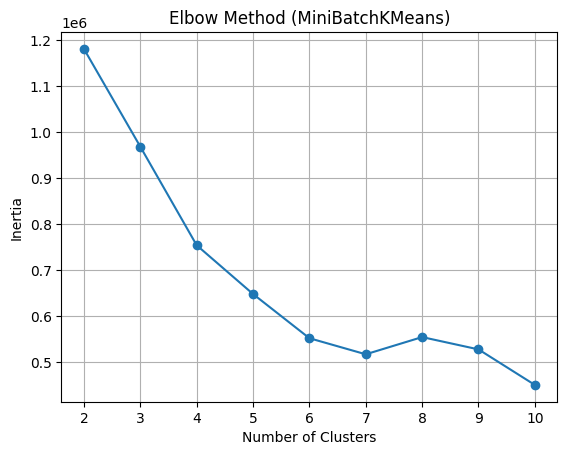

In [5]:
# Determine Optimal Clusters (Elbow Method) 

inertia = []
k_range = range(2, 11)

for k in k_range:
    mbkm = MiniBatchKMeans(n_clusters=k, batch_size=1000, random_state=42)
    mbkm.fit(X_scaled)
    inertia.append(mbkm.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method (MiniBatchKMeans)')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()


In [6]:
# Apply MiniBatch KMeans

k = 4  # Based on elbow method
mbkm = MiniBatchKMeans(n_clusters=k, batch_size=1000, random_state=42)
cluster_labels = mbkm.fit_predict(X_scaled)

# Add cluster labels to original DataFrame
df['Cluster'] = cluster_labels
df.head()


,MTL_CODE,PREFIX_MTL_CODE,MTL_DESC,DEPT,PSL_UNIT,STORE_CODE,IMP_IND,RATE,Cluster
0,4670263510,TR,cu det,206,NO,2,2,7138.60,0
1,4900107255,SG,relay vagm,209,NO,3,2,5420.33,0
2,4900107280,SG,relay vajh-13,209,NO,3,2,1300.93,0
3,4900107298,SG,relay vax31,209,NO,3,2,4428.94,0
4,4900107301,SG,relay dth31,209,NO,3,2,36412.03,0


In [7]:
from sklearn.metrics import silhouette_score

# Use a sample for faster silhouette computation
sample_size = 5000
sample_idx = np.random.choice(len(X_scaled), sample_size, replace=False)

score = silhouette_score(X_scaled[sample_idx], cluster_labels[sample_idx])
print(f"Silhouette Score (sample of {sample_size}): {score:.3f}")


Silhouette Score (sample of 5000): 0.419


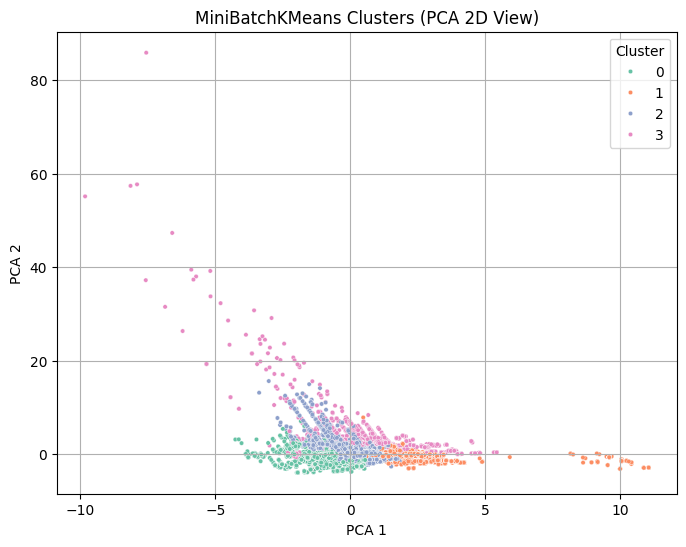

In [8]:
# Visualize cluster via PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=cluster_labels, palette='Set2', s=10)
plt.title("MiniBatchKMeans Clusters (PCA 2D View)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()
